# EDA (Exploratory Data Analysis)

가설 검증 전 데이터 분포와 이상점 그리고 결측치 확인하고   
분석 결과에 따라 통계 검증 방법(t-test vs Mann-Whitney U test)을 결정한다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
import os

sys.path.append(os.path.abspath('..'))

from etl.db import engine

In [2]:
orders = pd.read_sql('SELECT * FROM orders', engine)
reviews = pd.read_sql('SELECT * FROM reviews', engine)
payments = pd.read_sql('SELECT * FROM payments', engine)

print(orders.shape)
print(reviews.shape)
print(payments.shape)

(99441, 8)
(98410, 7)
(103886, 5)


In [3]:
print(orders.columns.tolist())
print(reviews.columns.tolist())
print(payments.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


## 1. 결측치 확인

분석 대상에서 제외되는 주문 규모를 파악한다.

In [4]:
missing = pd.DataFrame({
    'orders': [
        orders['order_delivered_customer_date'].isna().sum(),
        orders['order_estimated_delivery_date'].isna().sum(),
    ],
}, index=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
])

print(missing)
print(f"\norders total: {len(orders)}")
print(f"orders without delivery date: {orders['order_delivered_customer_date'].isna().sum()}")
print(f"orders without review: {len(orders) - orders['order_id'].isin(reviews['order_id']).sum()}")

                               orders
order_delivered_customer_date    2965
order_estimated_delivery_date       0

orders total: 99441
orders without delivery date: 2965
orders without review: 1274


## 2. 배송 지연 일수 분포

이상점 범위와 t-test 사용 가능 여부를 판단한다.

In [5]:
delivered = orders.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]).copy()

delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_estimated_delivery_date']
).dt.days

delay = delivered['delay_days']

print("=== Delay Days Basic Statistics ===")
print(f"count : {delay.count()}")
print(f"mean  : {delay.mean():.2f}")
print(f"median: {delay.median():.2f}")
print(f"std   : {delay.std():.2f}")
print(f"min   : {delay.min()}")
print(f"max   : {delay.max()}")
print(f"skew  : {delay.skew():.2f}")
print(f"kurt  : {delay.kurt():.2f}")

=== Delay Days Basic Statistics ===
count : 96476
mean  : -11.88
median: -12.00
std   : 10.18
min   : -147
max   : 188
skew  : 2.01
kurt  : 28.05


describe()는 기본 통계만 제공하므로 분포의 형태를 파악하기 위해   
왜도와 첨도를 포함한 통계를 별도로 계산했다.

In [17]:
early_count = (delay < 0).sum()
early_ratio = early_count / len(delay) * 100
ontime_count = (delay == 0).sum()
delayed_count = (delay > 0).sum()
delayed_ratio = delayed_count / len(delay) * 100

print(f"""
=== Delivery Timing Breakdown ===
early   (delay < 0) : {early_count:,} orders ({early_ratio:.1f}%)
on-time (delay = 0) : {ontime_count:,} orders ({ontime_count/len(delay)*100:.1f}%)
delayed (delay > 0) : {delayed_count:,} orders ({delayed_ratio:.1f}%)
""")


=== Delivery Timing Breakdown ===
early   (delay < 0) : 88,649 orders (91.9%)
on-time (delay = 0) : 1,292 orders (1.3%)
delayed (delay > 0) : 6,535 orders (6.8%)



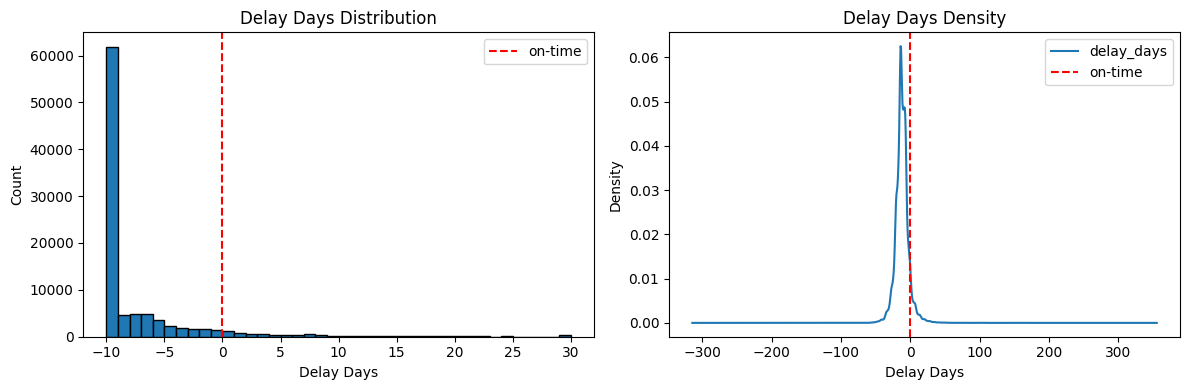

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(delay.clip(-10, 30), bins=40, edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', label='on-time')
axes[0].set_title('Delay Days Distribution')
axes[0].set_xlabel('Delay Days')
axes[0].set_ylabel('Count')
axes[0].legend()

delay.plot(kind='kde', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', label='on-time')
axes[1].set_title('Delay Days Density')
axes[1].set_xlabel('Delay Days')
axes[1].legend()

plt.tight_layout()
plt.show()

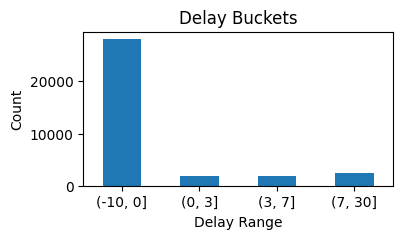

In [8]:
plt.figure(figsize=(4, 2))  

delay_bins = pd.cut(delay, bins=[-10, 0, 3, 7, 30])
delay_bins.value_counts().sort_index().plot(kind='bar')

plt.title('Delay Buckets')
plt.xlabel('Delay Range')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

## 3. 이상점 확인

IQR 기준으로 지연 일수의 이상점 범위를 확인한다.

In [9]:
Q1 = delay.quantile(0.25)
Q3 = delay.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = delay[(delay < lower) | (delay > upper)]

print(f"Q1      : {Q1:.2f}")
print(f"Q3      : {Q3:.2f}")
print(f"IQR     : {IQR:.2f}")
print(f"lower   : {lower:.2f}")
print(f"upper   : {upper:.2f}")
print(f"outliers: {len(outliers)} ({len(outliers)/len(delay)*100:.2f}%)")

Q1      : -17.00
Q3      : -7.00
IQR     : 10.00
lower   : -32.00
upper   : 8.00
outliers: 4301 (4.46%)


describe()는 기본적인 분포 요약만 제공하므로 IQR 기반 이상치 기준을 정의하고   
이상치 개수를 파악하기 위해 수동으로 계산했다.

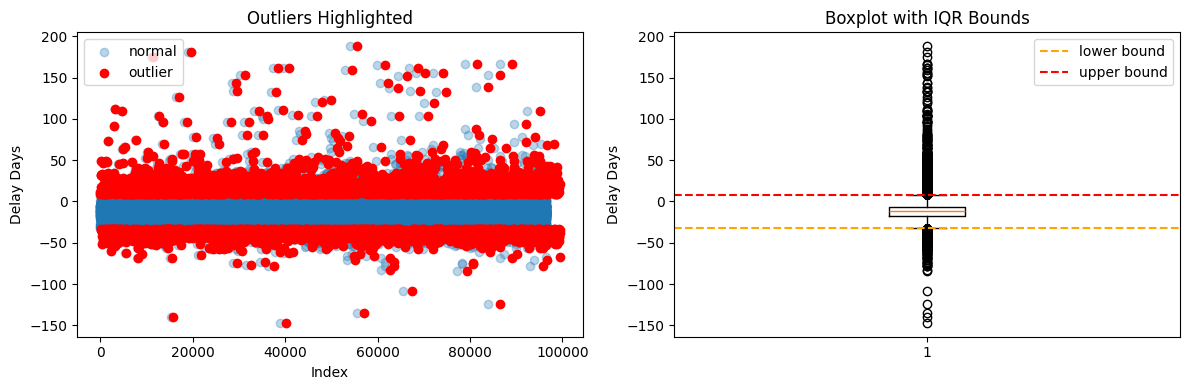

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(range(len(delay)), delay, alpha=0.3, label='normal')
axes[0].scatter(outliers.index, outliers, color='red', label='outlier')
axes[0].set_title('Outliers Highlighted')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Delay Days')
axes[0].legend()

axes[1].boxplot(delay.dropna(), vert=True)
axes[1].axhline(lower, color='orange', linestyle='--', label='lower bound')
axes[1].axhline(upper, color='red', linestyle='--', label='upper bound')
axes[1].set_title('Boxplot with IQR Bounds')
axes[1].set_ylabel('Delay Days')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
orders[['order_delivered_customer_date', 'order_estimated_delivery_date']].head()

,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-10 21:25:13,2017-10-18
1,2018-08-07 15:27:45,2018-08-13
2,2018-08-17 18:06:29,2018-09-04
3,2017-12-02 00:28:42,2017-12-15
4,2018-02-16 18:17:02,2018-02-26


IQR 기준으로 4,301건(4.46%)이 이상치로 탐지되었다.  
다만, 이는 단순한 데이터 오류라기보다는 지연 배송이 오른쪽으로 길게 늘어진  
비대칭 분포를 가지기 때문에 발생한 결과로 보인다.  

실제로 상위 경계가 약 8일로 계산되면서  
8일을 초과하는 지연 주문이 대부분 이상치로 분류되었다.  

이러한 지연 구간은 단순히 제거할 대상이 아니라  
고객 경험에 영향을 줄 수 있는 비즈니스 이벤트로 해석하는 것이 더 적절하다.


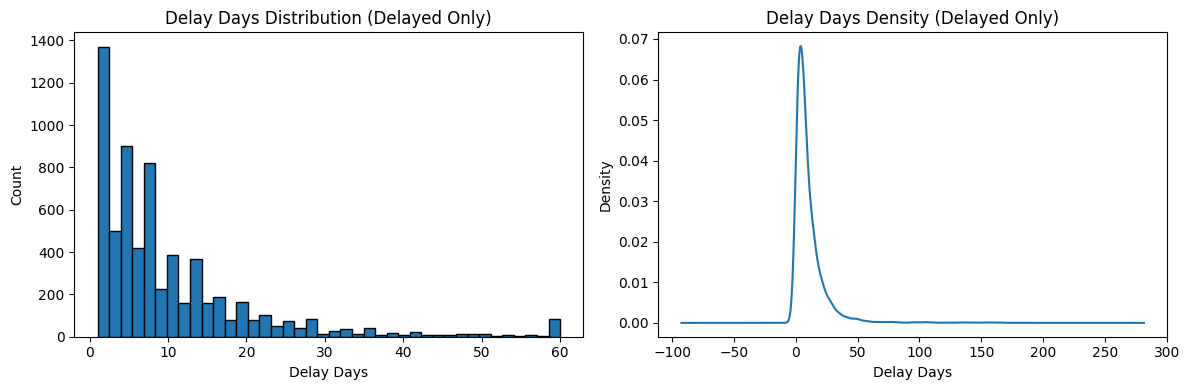

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

delayed_only = delay[delay > 0]

axes[0].hist(delayed_only.clip(0, 60), bins=40, edgecolor='black')
axes[0].set_title('Delay Days Distribution (Delayed Only)')
axes[0].set_xlabel('Delay Days')
axes[0].set_ylabel('Count')

delayed_only.plot(kind='kde', ax=axes[1])
axes[1].set_title('Delay Days Density (Delayed Only)')
axes[1].set_xlabel('Delay Days')

plt.tight_layout()
plt.show()

전체 주문 중 지연이 발생한 주문만 필터링하여 분포를 확인한 결과   
지연 주문은 단기 구간에 집중되어 있으면서 오른쪽으로 긴 꼬리를 가지는 비대칭 분포를 보였다.  

이러한 분포 특성으로 인해 IQR 기준이 지연 데이터에 과도하게 작동하는 것으로 보이며   
이상치 제거 대신 비즈니스 의미를 반영한 구간화 방식으로 분석을 진행한다.  

구간은 지연 분포 및 IQR 기준(약 8일)을 참고하여 다음과 같이 정의하였다.  

- **0일 이하** : 조기 배송  
- **0 ~ 3일** : 경미한 지연 (일반적인 변동 범위)  
- **3 ~ 7일** : 중간 수준 지연 (고객 불만 가능 구간)  
- **7일 초과** : 심각한 지연 (IQR 기준 상위 이상 구간)

## 4. 별점 분포

이탈 위험 고객(별점 1~2점) 비율을 확인한다.

=== Review Score Distribution ===
score 1: 11.46%
score 2: 3.16%
score 3: 8.23%
score 4: 19.31%
score 5: 57.83%

at-risk customers (score <= 2): 14.63%


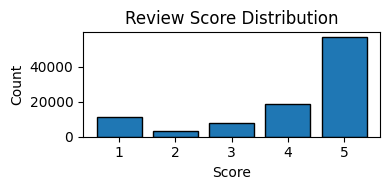

In [13]:
score_counts = reviews['review_score'].value_counts().sort_index()
score_ratio = (score_counts / len(reviews) * 100).round(2)

print("=== Review Score Distribution ===")
for score, ratio in score_ratio.items():
    print(f"score {score}: {ratio}%")

at_risk_ratio = reviews[reviews['review_score'] <= 2].shape[0] / len(reviews) * 100
print(f"\nat-risk customers (score <= 2): {at_risk_ratio:.2f}%")

plt.figure(figsize=(4, 2))
plt.bar(score_counts.index, score_counts.values, edgecolor='black')
plt.title('Review Score Distribution')
plt.xlabel('Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

describe()는 기본 통계 요약만 제공하고 각 점수별 빈도나 비율 및 조건별 비율은 제공하지 않기 때문에   
value_counts와 직접 계산을 사용했다.

## 5. 결제 금액 분포

ARPU 계산 전 이상점 여부를 확인한다.

In [18]:
order_payment = payments.groupby('order_id')['payment_value'].sum()

print("=== Payment Value Basic Statistics ===")
print(f"mean  : {order_payment.mean():.2f}")
print(f"median: {order_payment.median():.2f}")
print(f"std   : {order_payment.std():.2f}")
print(f"min   : {order_payment.min():.2f}")
print(f"max   : {order_payment.max():.2f}")
print(f"skew  : {order_payment.skew():.2f}")


=== Payment Value Basic Statistics ===
mean  : 160.99
median: 105.29
std   : 221.95
min   : 0.00
max   : 13664.08
skew  : 9.15


describe()는 기본 통계 요약만 제공하므로 우편향 분포 여부를 판단하기 위한 왜도와   
이상치 탐지를 위한 IQR 계산은 별도로 수행했다.

In [19]:
# IQR-based outlier check for payment values
Q1_p = order_payment.quantile(0.25)
Q3_p = order_payment.quantile(0.75)
IQR_p = Q3_p - Q1_p
lower_p = Q1_p - 1.5 * IQR_p
upper_p = Q3_p + 1.5 * IQR_p

outliers_p = order_payment[(order_payment < lower_p) | (order_payment > upper_p)]
outlier_ratio_p = len(outliers_p) / len(order_payment) * 100

print(f"""
=== Payment Outlier Check (IQR) ===
Q1      : {Q1_p:.2f} BRL
Q3      : {Q3_p:.2f} BRL
IQR     : {IQR_p:.2f} BRL
lower   : {lower_p:.2f} BRL
upper   : {upper_p:.2f} BRL
outliers: {len(outliers_p):,} orders ({outlier_ratio_p:.2f}%)
""")


=== Payment Outlier Check (IQR) ===
Q1      : 62.01 BRL
Q3      : 176.97 BRL
IQR     : 114.96 BRL
lower   : -110.43 BRL
upper   : 349.41 BRL
outliers: 7,866 orders (7.91%)



describe()는 IQR 기반 이상치 경계값과 이상치 건수 및 비율을 직접 제공하지 않기 때문에   
분위수를 수동으로 계산하고 이상치 여부를 별도로 집계했다.

In [20]:
# ARPU preview by delay group (bridge to hypothesis testing)
delay_label = pd.cut(
    delay,
    bins=[-float('inf'), 0, 3, 7, float('inf')],
    labels=['on_time', 'slight', 'moderate', 'severe']
)

payment_by_delay = (
    delivered
    .assign(delay_group=delay_label)
    .merge(
        order_payment.rename('payment_value'),
        left_on='order_id',
        right_index=True,
        how='left'
    )
    .groupby('delay_group', observed=True)['payment_value']
    .agg(median='median', mean='mean', count='count')
)

print("=== Median Payment Value by Delay Group (ARPU Preview) ===")
print(payment_by_delay)

=== Median Payment Value by Delay Group (ARPU Preview) ===
              median        mean  count
delay_group                            
on_time      104.610  158.669813  89941
slight       106.150  157.745412   1870
moderate     116.560  184.592253   1802
severe       118.845  182.840877   2862


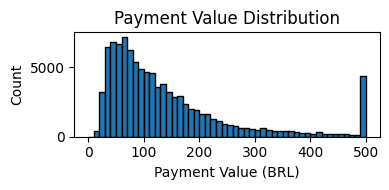

In [21]:
plt.figure(figsize=(4, 2))
plt.hist(order_payment.clip(0, 500), bins=50, edgecolor='black')
plt.title('Payment Value Distribution')
plt.xlabel('Payment Value (BRL)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 6. 누적 분포 확인

전체 주문 중 몇 %가 몇 일 이내 지연인지 확인한다.

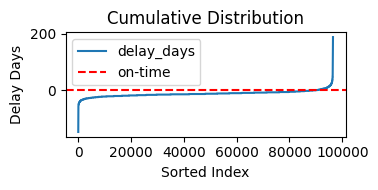

In [15]:
fig, axes = plt.subplots(1, 1, figsize=(4, 2))

sorted_delay = delay.sort_values().reset_index(drop=True)
sorted_delay.plot(ax=axes)
axes.axhline(0, color='red', linestyle='--', label='on-time')
axes.set_title('Cumulative Distribution')
axes.set_xlabel('Sorted Index')
axes.set_ylabel('Delay Days')
axes.legend()

plt.tight_layout()
plt.show()

In [22]:
# Bucket-level breakdown to support delay group design
total = len(delay)

thresholds = {
    'early   (delay <= 0)':     delay <= 0,
    'slight  (0 < delay <= 3)': (delay > 0) & (delay <= 3),
    'moderate(3 < delay <= 7)': (delay > 3) & (delay <= 7),
    'severe  (delay > 7)':      delay > 7,
}

print("=== Delay Bucket Distribution ===")
cumulative = 0
for label, mask in thresholds.items():
    count = mask.sum()
    ratio = count / total * 100
    cumulative += ratio
    print(f"{label}: {count:,} orders ({ratio:.1f}%) | cumulative {cumulative:.1f}%")


=== Delay Bucket Distribution ===
early   (delay <= 0): 89,941 orders (93.2%) | cumulative 93.2%
slight  (0 < delay <= 3): 1,870 orders (1.9%) | cumulative 95.2%
moderate(3 < delay <= 7): 1,802 orders (1.9%) | cumulative 97.0%
severe  (delay > 7): 2,863 orders (3.0%) | cumulative 100.0%


In [23]:
# Key ratios for hypothesis testing bridge
delayed_ratio   = (delay > 0).sum() / total * 100
within_7d_ratio = ((delay > 0) & (delay <= 7)).sum() / (delay > 0).sum() * 100
severe_ratio    = (delay > 7).sum() / total * 100

print(f"""
=== Key Ratios for Next Step ===
orders with any delay          : {delayed_ratio:.1f}%
delayed orders within 7 days   : {within_7d_ratio:.1f}%
orders with severe delay (>7d) : {severe_ratio:.1f}%
""")


=== Key Ratios for Next Step ===
orders with any delay          : 6.8%
delayed orders within 7 days   : 56.2%
orders with severe delay (>7d) : 3.0%



## 7. 정규성 검정

t-test 사용 가능 여부를 판단한다.   
표본이 크면(n > 30) 중심극한정리에 의해 t-test 사용 가능하다.   
Shapiro-Wilk test는 표본이 5000개 이하일 때만 신뢰할 수 있어 샘플로 확인한다.

In [16]:
sample = delay.dropna().sample(min(5000, len(delay)), random_state=42)
stat, p = stats.shapiro(sample)

print("=== Shapiro-Wilk Test (sample) ===")
print(f"statistic: {stat:.4f}")
print(f"p-value  : {p:.4f}")

if p > 0.05:
    print("result: normal distribution -> t-test available")
else:
    print("result: not normal distribution -> Mann-Whitney U test recommended")

=== Shapiro-Wilk Test (sample) ===
statistic: 0.7656
p-value  : 0.0000
result: not normal distribution -> Mann-Whitney U test recommended


## EDA Summary

| 항목 | 결과 |
|------|------|
| 배송일 결측 주문 | 2,965건 (2.98%) |
| 리뷰 없는 주문 | 1,274건 (1.28%) |
| 지연 일수 평균 | -11.88일 (조기 배송 경향 있으나 추가 검증 필요) |
| 지연 일수 이상점 비율 | 4,301건 (4.46%) — IQR 과도 작동, 데이터 오류 아님|
| 이탈 위험 고객 비율 | 14.63% (별점 1~2점) |
| 정규성 검정 결과 | p-value 0.0000 → 정규분포 아님 |
| 통계 검증 방법 | Mann-Whitney U test 사용 |

## 8. Summary & Next Step

EDA 결과, 지연 분포는 오른쪽으로 긴 꼬리를 가지는 비대칭 구조를 보였으며   
이로 인해 IQR 기준이 지연 데이터에 과도하게 작동하는 것으로 보인다.  

따라서 단일 기준이 아닌 구간 기반으로 지연을 정의하고   
각 구간별 이탈 위험 비율을 분석하여 임계값을 탐색한다.  

(→ 02_hypothesis_testing.ipynb에서 수행)